In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from loky import get_reusable_executor
from numpy.linalg import lstsq

In [155]:
def simulate(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200, rng=None):
    """Run one replicate of the adaptive-network SIR model.

    Parameters
    ----------
    beta : float in [0, 1]
        Transmission probability. At each time step, each S-I edge
        transmits the infection independently with probability beta.
        Higher beta means the disease spreads faster.
    gamma : float in [0, 1]
        Recovery probability. At each time step, each infected node
        recovers independently with probability gamma.
        Higher gamma means shorter infectious period (on average 1/gamma steps).
    rho : float in [0, 1]
        Rewiring probability. At each time step, each S-I edge is
        rewired independently with probability rho. The susceptible
        node drops the link to its infected neighbor and connects to
        a randomly chosen new node instead.
        Higher rho means more active social distancing behavior.
    N : int, default=200
        Number of nodes (individuals) in the network.
    p_edge : float, default=0.05
        Probability of an edge between any two nodes in the initial
        Erdos-Renyi random graph. Expected initial degree is (N-1)*p_edge.
        With N=200 and p_edge=0.05, the expected degree is about 10.
    n_infected0 : int, default=5
        Number of nodes infected at time t=0. These are chosen
        uniformly at random (without replacement) from all N nodes.
    T : int, default=200
        Number of discrete time steps to simulate.
    rng : numpy.random.Generator or None
        Random number generator for reproducibility. If None, a new
        generator is created with an arbitrary seed. Pass
        np.random.default_rng(seed) for reproducible runs.

    Returns
    -------
    infected_fraction : np.ndarray, shape (T+1,)
        Fraction of the population that is infected at each time step,
        from t=0 to t=T. Values are in [0, 1].
    rewire_counts : np.ndarray, shape (T+1,)
        Number of successful rewiring events at each time step.
        Always 0 at t=0 (no rewiring before the simulation starts).
    degree_histogram : np.ndarray, shape (31,)
        Histogram of node degrees at the final time step t=T.
        degree_histogram[d] = number of nodes with degree d, for d=0..29.
        degree_histogram[30] counts all nodes with degree >= 30.
    """
    if rng is None:
        rng = np.random.default_rng()

    # =====================================================================
    # STEP 0: Build the initial contact network as an Erdos-Renyi graph.
    #
    # We represent the network as an adjacency list using Python sets.
    # neighbors[i] is the set of node indices connected to node i.
    # Sets allow O(1) lookups for "is j a neighbor of i?" and efficient
    # add/remove operations, which is important for the rewiring step.
    #
    # For each pair (i, j) with i < j, we add an edge with probability
    # p_edge. This produces an undirected graph (if i is connected to j,
    # then j is also connected to i).
    # =====================================================================
    neighbors = [set() for _ in range(N)]
    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() < p_edge:
                neighbors[i].add(j)
                neighbors[j].add(i)

    # =====================================================================
    # Initialize the health state of each node.
    #
    # We encode states as integers:
    #   0 = Susceptible (S): can catch the disease
    #   1 = Infected (I):    currently infectious
    #   2 = Recovered (R):   immune, cannot be infected again
    #
    # At t=0, we pick n_infected0 nodes uniformly at random to be infected.
    # All other nodes start as susceptible.
    # =====================================================================
    state = np.zeros(N, dtype=np.int8)
    initial_infected = rng.choice(N, size=n_infected0, replace=False)
    state[initial_infected] = 1

    # Arrays to record the summary statistics at each time step
    infected_fraction = np.zeros(T + 1)
    rewire_counts = np.zeros(T + 1, dtype=np.int64)
    infected_fraction[0] = np.sum(state == 1) / N

    # =================================================================
    # Main simulation loop: iterate over T discrete time steps.
    # Each time step has three phases applied in order:
    #   Phase 1: Infection (S -> I transitions)
    #   Phase 2: Recovery  (I -> R transitions)
    #   Phase 3: Rewiring  (network topology changes)
    # =================================================================
    for t in range(1, T + 1):

        # =============================================================
        # PHASE 1: INFECTION (synchronous update)
        #
        # For every infected node i, look at each of its neighbors j.
        # If j is susceptible (state 0), the infection transmits with
        # probability beta.
        #
        # Important: we use synchronous (parallel) updating. We first
        # collect ALL new infections in a set, then apply them all at
        # once. This prevents "chain infections" within a single step
        # (where a newly infected node immediately infects its own
        # neighbors in the same step).
        # =============================================================
        new_infections = set()
        infected_nodes = np.where(state == 1)[0]

        for i in infected_nodes:
            for j in neighbors[i]:
                if state[j] == 0:  # j is susceptible
                    if rng.random() < beta:
                        new_infections.add(j)

        # Apply all new infections at once (synchronous update)
        for j in new_infections:
            state[j] = 1

        # =============================================================
        # PHASE 2: RECOVERY
        #
        # Each currently infected node (including those just infected
        # in Phase 1) recovers independently with probability gamma.
        # Recovery is permanent: recovered nodes move to state 2 (R)
        # and can never be infected again.
        #
        # We recompute the infected set to include newly infected nodes.
        # =============================================================
        infected_nodes = np.where(state == 1)[0]
        for i in infected_nodes:
            if rng.random() < gamma:
                state[i] = 2

        # =============================================================
        # PHASE 3: NETWORK REWIRING (adaptive behavior)
        #
        # This is what makes the model "adaptive": the network structure
        # changes in response to the disease.
        #
        # We look at all edges between a susceptible node (S) and an
        # infected node (I), called "S-I edges". For each such edge,
        # with probability rho, the susceptible node:
        #   1. Drops the connection to its infected neighbor
        #   2. Forms a new connection to a randomly chosen other node
        #      (that it is not already connected to)
        #
        # This models social distancing: susceptible individuals
        # actively avoid infected contacts.
        # =============================================================
        rewire_count = 0

        # First, collect all S-I edges. We iterate over susceptible
        # nodes and check their neighbors for infected ones.
        si_edges = []
        for i in range(N):
            if state[i] == 0:  # node i is susceptible
                for j in neighbors[i]:
                    if state[j] == 1:  # neighbor j is infected
                        si_edges.append((i, j))

        # Process each S-I edge for potential rewiring
        for s_node, i_node in si_edges:
            if rng.random() < rho:
                # Check that this edge still exists. An earlier rewiring
                # in this same loop may have already removed it (since
                # rewiring can affect shared neighborhoods).
                if i_node not in neighbors[s_node]:
                    continue

                # Remove the S-I edge (break the link in both directions)
                neighbors[s_node].discard(i_node)
                neighbors[i_node].discard(s_node)

                # Find all valid candidates for a new connection:
                # any node that is not s_node itself and not already
                # a neighbor of s_node. Note that the new partner can
                # be in any state (S, I, or R).
                candidates = []
                for k in range(N):
                    if k != s_node and k not in neighbors[s_node]:
                        candidates.append(k)

                # If there is at least one valid candidate, pick one
                # uniformly at random and create the new edge
                if candidates:
                    new_partner = rng.choice(candidates)
                    neighbors[s_node].add(new_partner)
                    neighbors[new_partner].add(s_node)
                    rewire_count += 1

        # Record summary statistics for this time step
        infected_fraction[t] = np.sum(state == 1) / N
        rewire_counts[t] = rewire_count

    # =====================================================================
    # Compute the degree histogram at the final time step.
    #
    # The degree of a node is its number of connections (neighbors).
    # We bin degrees from 0 to 29 individually, and lump all degrees >= 30
    # into a single bin (index 30). This gives a fixed-size output array
    # of shape (31,) regardless of the actual degree distribution.
    # =====================================================================
    degree_histogram = np.zeros(31, dtype=np.int64)
    for i in range(N):
        deg = min(len(neighbors[i]), 30)
        degree_histogram[deg] += 1

    return infected_fraction, rewire_counts, degree_histogram


In [ ]:
#import real data and reorganize
from pathlib import Path

data_dir = Path("data")

real_final_degree_histogram = pd.read_csv(data_dir / "final_degree_histograms.csv")
real_infected_fraction = pd.read_csv(data_dir / "infected_timeseries.csv")
real_rewire_counts = pd.read_csv(data_dir / "rewiring_timeseries.csv")


real_infected_matrix = real_infected_fraction.pivot_table(
    index='replicate_id', 
    columns='time', 
    values='infected_fraction'
).reset_index(drop=True).values

real_rewire_matrix = real_rewire_counts.pivot_table(
    index='replicate_id', 
    columns='time', 
    values='rewire_count'
).reset_index(drop=True).values

real_degree_matrix = real_final_degree_histogram.pivot_table(
    index='replicate_id', 
    columns='degree', 
    values='count',
    fill_value=0
).reset_index(drop=True).values

R_obs = real_infected_matrix.shape[0]
print(f"Infected fraction matrix shape: {real_infected_matrix.shape}")
print(f"Rewire counts matrix shape: {real_rewire_matrix.shape}")
print(f"Degree histogram matrix shape: {real_degree_matrix.shape}")

Infected fraction matrix shape: (40, 201)
Rewire counts matrix shape: (40, 201)
Degree histogram matrix shape: (40, 31)


In [157]:
# AI is used to improve simulation speed.
#simulation
N_sim = 50000
def run_one(_):
    beta = np.random.uniform(0.05, 0.5)
    gamma = np.random.uniform(0.02, 0.2)
    rho = np.random.uniform(0, 0.8)
    infected, rewires, degree = simulate(beta, gamma, rho)
    return beta, gamma, rho, infected, rewires, degree

executor = get_reusable_executor()
results = list(executor.map(run_one, range(N_sim)))

beta_arr = np.array([r[0] for r in results])
gamma_arr = np.array([r[1] for r in results])
rho_arr = np.array([r[2] for r in results])
generated_infected_fraction_lst = [r[3] for r in results]
generated_rewire_counts_lst = [r[4] for r in results]
generated_final_degree_histogram_lst = [r[5] for r in results]


In [172]:
#define summary statistics
def summary_infected(infected_fraction):
    peak_val = np.max(infected_fraction)
    peak_time = np.argmax(infected_fraction)
    t_early = np.arange(20)
    slope, _ = np.polyfit(t_early, infected_fraction[:20], 1)
    early_growth_slope = slope
    return np.array([peak_val, peak_time, early_growth_slope])

def summary_rewire(rewire_counts, infected_fraction):
    total = np.sum(rewire_counts) / 1000.0

    I_count = infected_fraction * 200.0
    mask = I_count > 5  # only when enough infected
    if mask.sum() > 0:
        ratio = np.mean(rewire_counts[mask] / I_count[mask])
    else:
        ratio = 0.0

    return np.array([total, ratio])

def summary_degree(degree_histogram):
    degrees = np.arange(31)
    total = np.sum(degree_histogram)
    if total == 0:
        return np.array([0.0, 0.0, 0.0, 0.0])

    probs = degree_histogram / total
    mean_deg = np.sum(degrees * probs)
    var_deg = np.sum((degrees - mean_deg) ** 2 * probs)
    std_deg = np.sqrt(var_deg)

    return np.array([std_deg / 30.0])

def full_summary(infected_fraction, rewire_counts, degree_histogram):
    s1 = summary_infected(infected_fraction)                    
    s2 = summary_rewire(rewire_counts, infected_fraction)       
    s3 = summary_degree(degree_histogram)                       
    return np.concatenate([s1, s2, s3])

In [173]:
#summary statistics for observed data
obs_summaries = []
for r in range(R_obs):
    s = full_summary(
        real_infected_matrix[r],
        real_rewire_matrix[r],
        real_degree_matrix[r]
    )
    obs_summaries.append(s)

obs_summaries = np.array(obs_summaries) 
obs_summary_mean = obs_summaries.mean(axis=0)


In [174]:
# Summary statistics for simulated data
sim_summaries = np.array([
    full_summary(inf, rew, deg)
    for inf, rew, deg in zip(
        generated_infected_fraction_lst,
        generated_rewire_counts_lst,
        generated_final_degree_histogram_lst
    )
])

In [175]:
# Basic Rejection ABC
# Normalize using simulated statistics
sim_mean = sim_summaries.mean(axis=0)
sim_std  = sim_summaries.std(axis=0)
sim_std[sim_std == 0] = 1.0 

sim_norm = (sim_summaries - sim_mean) / sim_std
obs_norm = (obs_summary_mean - sim_mean) / sim_std

# Euclidean distance between each simulation and the observed summary
distances = np.linalg.norm(sim_norm - obs_norm, axis=1)

quantile = 0.05
epsilon = np.quantile(distances, quantile)
accepted = distances <= epsilon

beta_accepted_summary  = beta_arr[accepted]
gamma_accepted_summary = gamma_arr[accepted]
rho_accepted_summary   = rho_arr[accepted]


In [176]:
#calculate and print posterior median and std
beta_median = np.median(beta_accepted_summary)
beta_std = np.std(beta_accepted_summary)
gamma_median = np.median(gamma_accepted_summary)
gamma_std = np.std(gamma_accepted_summary)
rho_median = np.median(rho_accepted_summary)
rho_std = np.std(rho_accepted_summary)
print(f"Posterior median and std:")
print(f"beta:  median={beta_median:.4f}, std={beta_std:.4f}")
print(f"gamma: median={gamma_median:.4f}, std={gamma_std:.4f}")
print(f"rho:   median={rho_median:.4f}, std={rho_std:.4f}")

Posterior median and std:
beta:  median=0.1904, std=0.0643
gamma: median=0.0775, std=0.0273
rho:   median=0.3412, std=0.1202


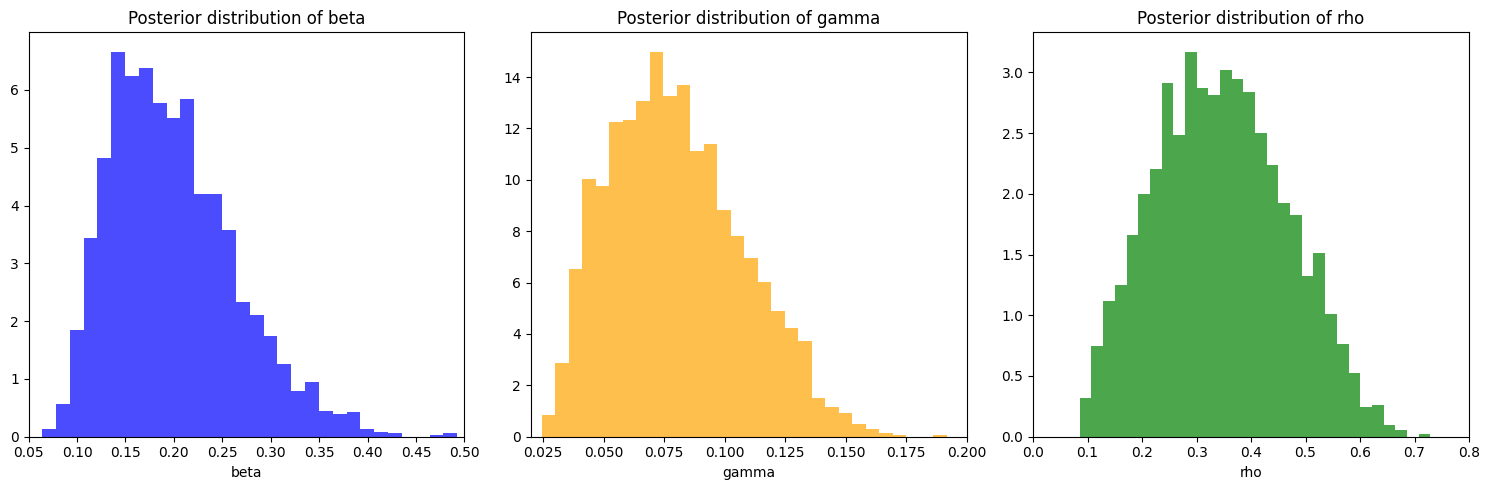

In [177]:
#plot beta, gamma, and rho
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(beta_accepted_summary, bins=30, density=True, alpha=0.7, color='blue')
plt.xlim(0.05, 0.5)
plt.title('Posterior distribution of beta')
plt.xlabel('beta')
plt.subplot(1, 3, 2)
plt.hist(gamma_accepted_summary, bins=30, density=True, alpha=0.7, color='orange')
plt.xlim(0.02, 0.2)
plt.title('Posterior distribution of gamma')
plt.xlabel('gamma')
plt.subplot(1, 3, 3)
plt.hist(rho_accepted_summary, bins=30, density=True, alpha=0.7, color='green')
plt.xlim(0, 0.8)
plt.title('Posterior distribution of rho')
plt.xlabel('rho')
plt.tight_layout()
plt.show()

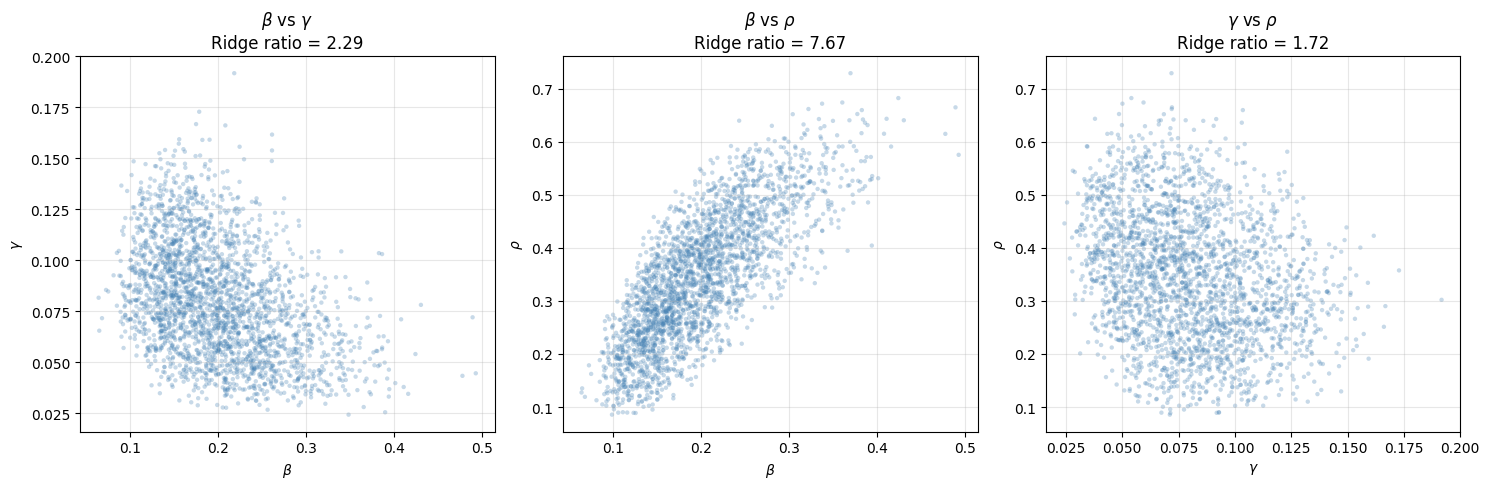

In [178]:
# AI is used to generate this part.
# Joint posteriors of all three parameter pairs (simplified)
from scipy.stats import pearsonr

pairs = [
    (r"$\beta$", r"$\gamma$", beta_accepted_summary, gamma_accepted_summary),
    (r"$\beta$", r"$\rho$",   beta_accepted_summary, rho_accepted_summary),
    (r"$\gamma$", r"$\rho$",  gamma_accepted_summary, rho_accepted_summary),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (xlab, ylab, x, y) in zip(axes, pairs):
    ax.scatter(x, y, s=10, alpha=0.3, color="steelblue", edgecolor="none")

    # Standardized ridge ratio
    xs = (x - x.mean()) / x.std()
    ys = (y - y.mean()) / y.std()
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack([xs, ys])))[::-1]
    ridge_ratio = eigvals[0] / eigvals[1]

    ax.set_title(f"{xlab} vs {ylab}\nRidge ratio = {ridge_ratio:.2f}")
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

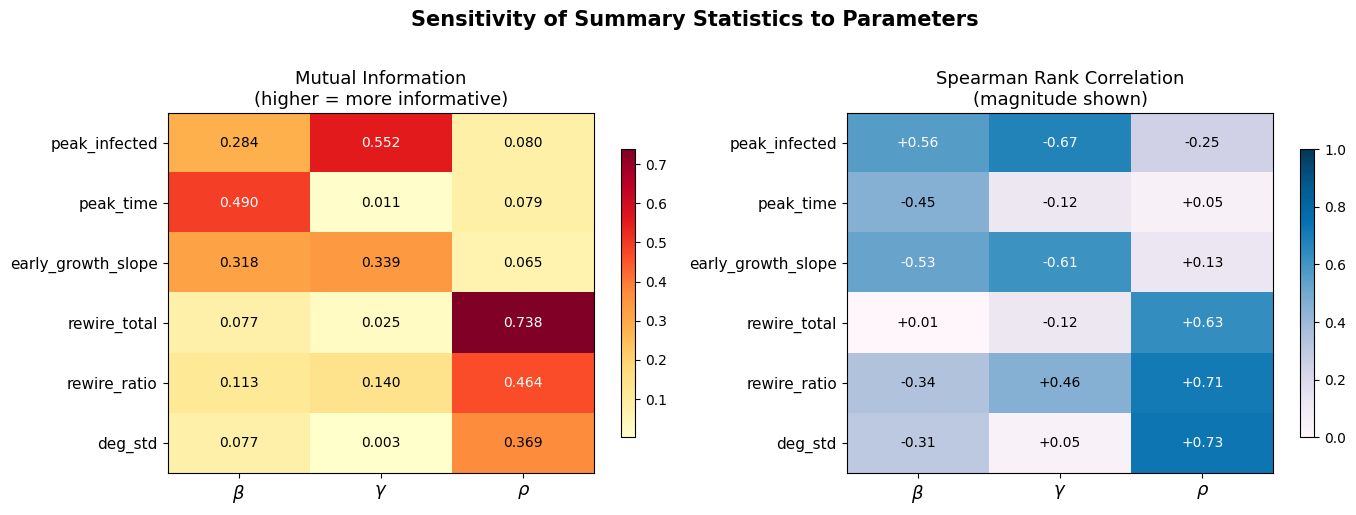


MI-based informativeness ranking (per parameter):
  beta: peak_time (0.490), early_growth_slope (0.318), peak_infected (0.284), rewire_ratio (0.113), deg_std (0.077), rewire_total (0.077)
  gamma: peak_infected (0.552), early_growth_slope (0.339), rewire_ratio (0.140), rewire_total (0.025), peak_time (0.011), deg_std (0.003)
  rho: rewire_total (0.738), rewire_ratio (0.464), deg_std (0.369), peak_infected (0.080), peak_time (0.079), early_growth_slope (0.065)


In [179]:
# ============================================================
# AI is used to generate this part.
# Sensitivity Test 1: Mutual Information & Spearman Correlation
# ============================================================
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression

stat_names = [
    "peak_infected",
    "peak_time",
    "early_growth_slope",
    "rewire_total",
    "rewire_ratio",
    "deg_std",
]
param_names  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
param_arrays = np.column_stack([beta_arr, gamma_arr, rho_arr])

n_stats  = len(stat_names)
n_params = 3

# --- Mutual Information matrix ---
MI = np.zeros((n_stats, n_params))
for j in range(n_params):
    # mutual_info_regression treats each column of X as a feature
    # and estimates MI with the target y
    for i in range(n_stats):
        MI[i, j] = mutual_info_regression(
            sim_summaries[:, i].reshape(-1, 1),
            param_arrays[:, j],
            n_neighbors=10,
            random_state=42
        )[0]

# --- Spearman correlation matrix ---
SPEARMAN = np.zeros((n_stats, n_params))
for i in range(n_stats):
    for j in range(n_params):
        rho_val, _ = spearmanr(sim_summaries[:, i], param_arrays[:, j])
        SPEARMAN[i, j] = rho_val

# --- Plot side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MI heatmap
im1 = ax1.imshow(MI, cmap="YlOrRd", aspect="auto")
ax1.set_xticks(range(n_params))
ax1.set_xticklabels(param_names, fontsize=13)
ax1.set_yticks(range(n_stats))
ax1.set_yticklabels(stat_names, fontsize=11)
ax1.set_title("Mutual Information\n(higher = more informative)", fontsize=13)
for i in range(n_stats):
    for j in range(n_params):
        ax1.text(j, i, f"{MI[i,j]:.3f}", ha="center", va="center",
                 fontsize=10, color="white" if MI[i,j] > MI.max()*0.6 else "black")
fig.colorbar(im1, ax=ax1, shrink=0.8)

# Spearman heatmap (absolute values for color, annotate with sign)
im2 = ax2.imshow(np.abs(SPEARMAN), cmap="PuBu", aspect="auto", vmin=0, vmax=1)
ax2.set_xticks(range(n_params))
ax2.set_xticklabels(param_names, fontsize=13)
ax2.set_yticks(range(n_stats))
ax2.set_yticklabels(stat_names, fontsize=11)
ax2.set_title("Spearman Rank Correlation\n(magnitude shown)", fontsize=13)
for i in range(n_stats):
    for j in range(n_params):
        ax2.text(j, i, f"{SPEARMAN[i,j]:+.2f}", ha="center", va="center",
                 fontsize=10, color="white" if abs(SPEARMAN[i,j]) > 0.5 else "black")
fig.colorbar(im2, ax=ax2, shrink=0.8)

fig.suptitle("Sensitivity of Summary Statistics to Parameters",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- Print ranking ---
print("\n" + "="*60)
print("MI-based informativeness ranking (per parameter):")
print("="*60)
for j, pname in enumerate(["beta", "gamma", "rho"]):
    order = np.argsort(-MI[:, j])
    print(f"  {pname}: ", end="")
    print(", ".join(f"{stat_names[k]} ({MI[k,j]:.3f})" for k in order))

# Advanced Method 1: linear Regression

In [180]:
# ============================================================
#AI is used to help generate this part.
# ABC with Local-Linear Regression Adjustment 
# ============================================================

# Step 1: Normalize (same as before)
sim_mean = sim_summaries.mean(axis=0)
sim_std  = sim_summaries.std(axis=0)
sim_std[sim_std == 0] = 1.0

sim_norm = (sim_summaries - sim_mean) / sim_std
obs_norm = (obs_summary_mean - sim_mean) / sim_std

# Step 2: Compute distances and set tolerance
distances = np.linalg.norm(sim_norm - obs_norm, axis=1)
quantile = 0.05
epsilon = np.quantile(distances, quantile)

# Step 3: Epanechnikov kernel weights (smooth weighting)
# K(t) = 1 - (t/epsilon)^2  for t <= epsilon, else 0
weights = np.where(
    distances <= epsilon,
    1.0 - (distances / epsilon) ** 2,
    0.0
)

# Boolean mask for accepted points (those with nonzero weight)
accepted = weights > 0

# Step 4: Local-linear regression adjustment
def regression_adjust(param_values, sim_stats_norm, obs_stats_norm, wts, mask):
    phi = param_values[mask]       
    S = sim_stats_norm[mask]        
    w = wts[mask]                   
    
    diff = S - obs_stats_norm      
    X = np.column_stack([np.ones(len(phi)), diff])  
    
    # Weighted least squares: minimize sum_i w_i * (phi_i - X_i @ coeffs)^2
    W_sqrt = np.sqrt(w)
    X_w = X * W_sqrt[:, None]          # weight rows of X
    phi_w = phi * W_sqrt               # weight response
    
    coeffs, _, _, _ = lstsq(X_w, phi_w, rcond=None)
    
    # coeffs[0] = alpha (intercept = posterior mean estimate)
    # coeffs[1:] = beta (regression slopes)
    beta_hat = coeffs[1:]
    
    # Regression adjustment: shift each accepted param to where s_i = s_obs
    phi_adjusted = phi - diff @ beta_hat
    
    return phi_adjusted, w

# Apply regression adjustment to each parameter
beta_adjusted, w_accepted = regression_adjust(
    beta_arr, sim_norm, obs_norm, weights, accepted
)
gamma_adjusted, _ = regression_adjust(
    gamma_arr, sim_norm, obs_norm, weights, accepted
)
rho_adjusted, _ = regression_adjust(
    rho_arr, sim_norm, obs_norm, weights, accepted
)

# For comparison, also keep the plain rejection results
beta_accepted_summary  = beta_arr[accepted]
gamma_accepted_summary = gamma_arr[accepted]
rho_accepted_summary   = rho_arr[accepted]

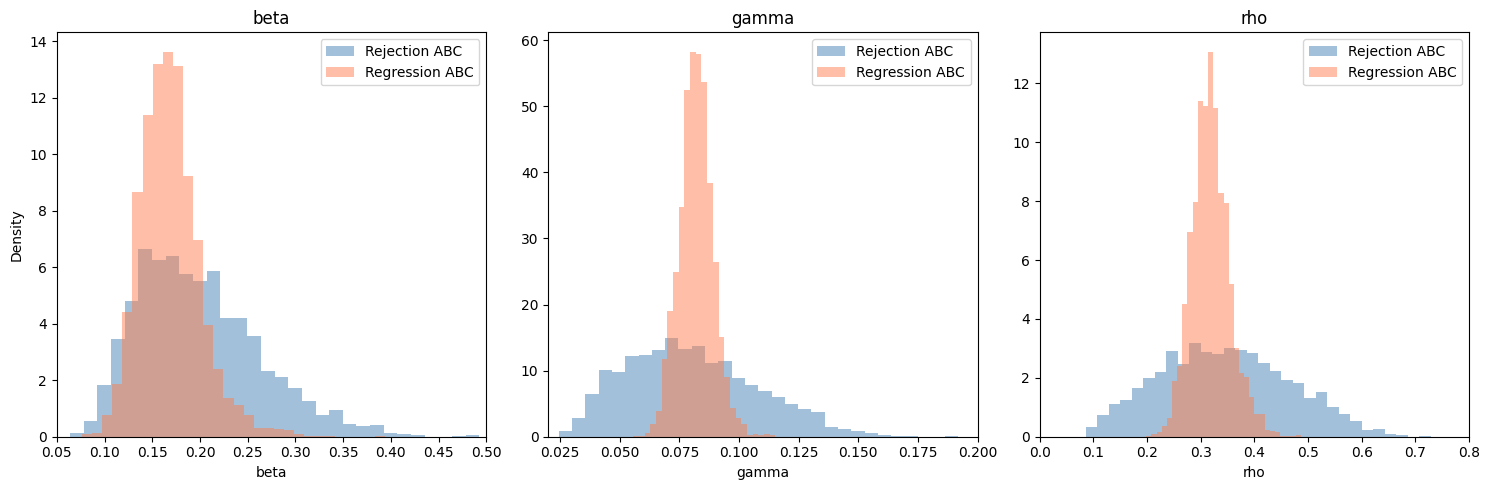

In [181]:
#plot the comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

params = [
    ('beta',  0.05, 0.5,  beta_accepted_summary,  beta_adjusted,  w_accepted),
    ('gamma', 0.02, 0.2,  gamma_accepted_summary,  gamma_adjusted, w_accepted),
    ('rho',   0.0,  0.8,  rho_accepted_summary,    rho_adjusted,   w_accepted),
]

for col, (name, lo, hi, rejected_vals, adjusted_vals, wts) in enumerate(params):
    axes[col].hist(rejected_vals, bins=30, density=True, alpha=0.5,
                   color='steelblue', label='Rejection ABC')
    axes[col].hist(adjusted_vals, bins=30, density=True, alpha=0.5,
                   weights=wts, color='coral', label='Regression ABC')
    axes[col].set_xlim(lo, hi)
    axes[col].set_title(name)
    axes[col].set_xlabel(name)
    axes[col].legend()

axes[0].set_ylabel('Density')
plt.tight_layout()
plt.show()

# Advanced Method 2: ABC-MCMC

In [182]:
#AI assistance was used to review and organize the structure of the ABC-MCMC helper functions
def abc_distance(beta, gamma, rho, rng=None):
    infected, rewires, degree = simulate(beta, gamma, rho, rng=rng)
    s = full_summary(infected, rewires, degree)
    s_norm = (s - sim_mean) / sim_std
    d = np.linalg.norm(s_norm - obs_norm)
    return d, s

In [183]:
#AI assistance was used to review and organize the structure of the ABC-MCMC helper functions
def in_prior_support(theta):
    beta, gamma, rho = theta
    return (0.05 <= beta <= 0.5) and (0.02 <= gamma <= 0.2) and (0.0 <= rho <= 0.8)

def propose_theta(theta, proposal_scales, rng):
    """
    Symmetric Gaussian random-walk proposal.
    """
    return theta + rng.normal(0.0, proposal_scales, size=3)

def abc_mcmc(
    n_steps,
    init_theta,
    epsilon,
    proposal_scales=(0.02, 0.01, 0.03),
    seed=123
):
    rng = np.random.default_rng(seed)

    chain = np.zeros((n_steps, 3))
    distances_chain = np.zeros(n_steps)
    accepted_flags = np.zeros(n_steps, dtype=bool)

    current_theta = np.array(init_theta, dtype=float)
    current_d, _ = abc_distance(*current_theta, rng=rng)

    chain[0] = current_theta
    distances_chain[0] = current_d

    for t in range(1, n_steps):
        proposal = propose_theta(current_theta, np.array(proposal_scales), rng)

        # Outside prior support => reject immediately
        if not in_prior_support(proposal):
            chain[t] = current_theta
            distances_chain[t] = current_d
            continue

        proposal_d, _ = abc_distance(*proposal, rng=rng)

        # Uniform prior + symmetric proposal => MH ratio cancels
        if proposal_d <= epsilon:
            current_theta = proposal
            current_d = proposal_d
            accepted_flags[t] = True

        chain[t] = current_theta
        distances_chain[t] = current_d

    acceptance_rate = accepted_flags.mean()

    return {
        "chain": chain,
        "distances": distances_chain,
        "accepted_flags": accepted_flags,
        "acceptance_rate": acceptance_rate
    }

In [194]:
# Start chain from one accepted rejection-ABC sample
accepted_thetas = np.column_stack([
    beta_accepted_summary,
    gamma_accepted_summary,
    rho_accepted_summary
])

rng_init = np.random.default_rng(2026)
init_theta = accepted_thetas[rng_init.integers(len(accepted_thetas))]
init_theta

array([0.16406018, 0.06727369, 0.25226699])

In [185]:
n_steps = 2000
proposal_scales = np.array([0.015, 0.008, 0.025])  # can tune
epsilon_mcmc = epsilon  # use the same epsilon as rejection ABC first

mcmc_result = abc_mcmc(
    n_steps=n_steps,
    init_theta=init_theta,
    epsilon=epsilon_mcmc,
    proposal_scales=proposal_scales,
    seed=42
)

chain = mcmc_result["chain"]
dist_chain = mcmc_result["distances"]
accepted_flags = mcmc_result["accepted_flags"]

print("Acceptance rate:", mcmc_result["acceptance_rate"])

Acceptance rate: 0.543


In [186]:
burn_in = 500
thin = 10

posterior_chain = chain[burn_in::thin]

beta_mcmc = posterior_chain[:, 0]
gamma_mcmc = posterior_chain[:, 1]
rho_mcmc = posterior_chain[:, 2]

print("Posterior sample size after burn-in/thinning:", len(posterior_chain))

Posterior sample size after burn-in/thinning: 150


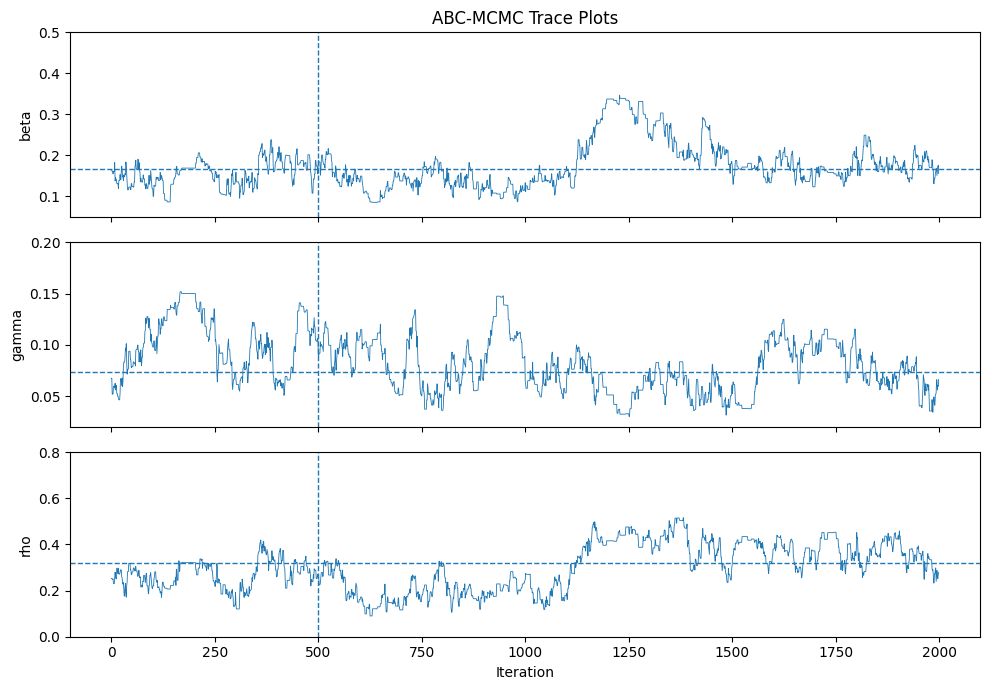

In [187]:
burn = 500

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# beta
axes[0].plot(chain[:, 0], lw=0.6)
axes[0].axvline(burn, linestyle="--", linewidth=1)  # burn-in
axes[0].axhline(np.median(chain[burn:, 0]), linestyle="--", linewidth=1)  # median
axes[0].set_ylabel("beta")
axes[0].set_ylim(0.05, 0.50)
axes[0].set_title("ABC-MCMC Trace Plots")

# gamma
axes[1].plot(chain[:, 1], lw=0.6)
axes[1].axvline(burn, linestyle="--", linewidth=1)
axes[1].axhline(np.median(chain[burn:, 1]), linestyle="--", linewidth=1)
axes[1].set_ylabel("gamma")
axes[1].set_ylim(0.02, 0.20)

# rho
axes[2].plot(chain[:, 2], lw=0.6)
axes[2].axvline(burn, linestyle="--", linewidth=1)
axes[2].axhline(np.median(chain[burn:, 2]), linestyle="--", linewidth=1)
axes[2].set_ylabel("rho")
axes[2].set_ylim(0.00, 0.80)
axes[2].set_xlabel("Iteration")

plt.tight_layout()
plt.show()

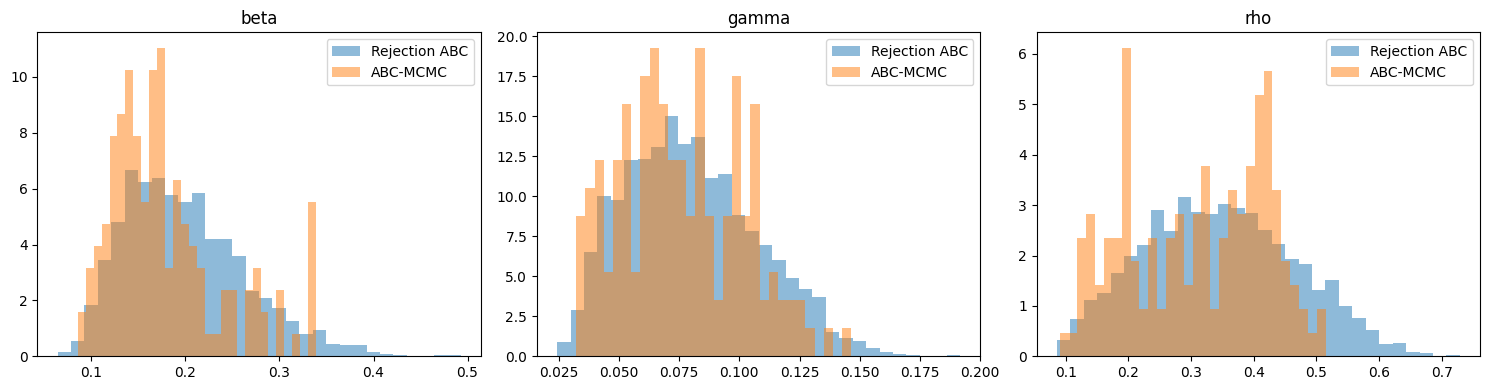

In [195]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(beta_accepted_summary, bins=30, density=True, alpha=0.5, label="Rejection ABC")
axes[0].hist(beta_mcmc, bins=30, density=True, alpha=0.5, label="ABC-MCMC")
axes[0].set_title("beta")
axes[0].legend()

axes[1].hist(gamma_accepted_summary, bins=30, density=True, alpha=0.5, label="Rejection ABC")
axes[1].hist(gamma_mcmc, bins=30, density=True, alpha=0.5, label="ABC-MCMC")
axes[1].set_title("gamma")
axes[1].legend()

axes[2].hist(rho_accepted_summary, bins=30, density=True, alpha=0.5, label="Rejection ABC")
axes[2].hist(rho_mcmc, bins=30, density=True, alpha=0.5, label="ABC-MCMC")
axes[2].set_title("rho")
axes[2].legend()

plt.tight_layout()
plt.show()

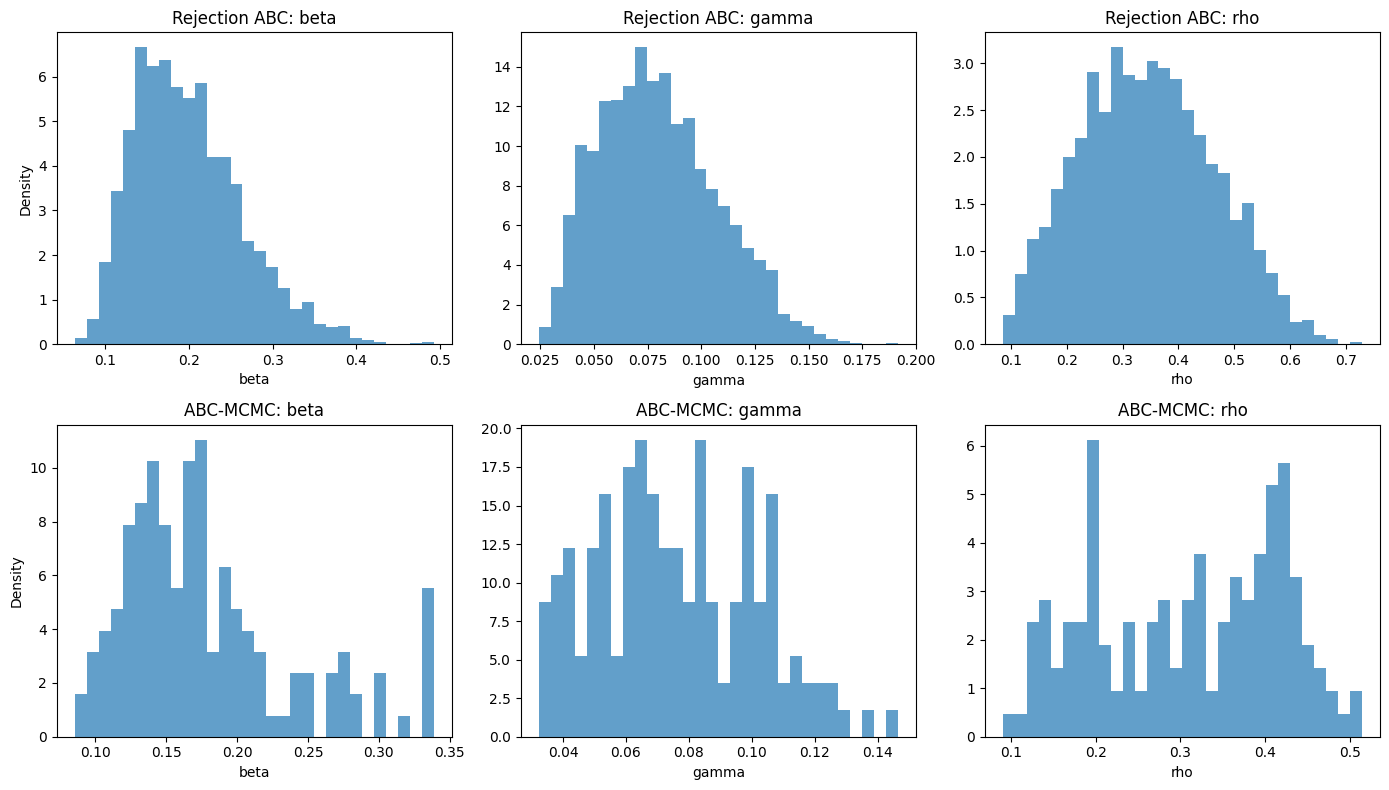

In [189]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Rejection ABC
axes[0, 0].hist(beta_accepted_summary, bins=30, density=True, alpha=0.7)
axes[0, 0].set_title("Rejection ABC: beta")
axes[0, 0].set_xlabel("beta")
axes[0, 0].set_ylabel("Density")

axes[0, 1].hist(gamma_accepted_summary, bins=30, density=True, alpha=0.7)
axes[0, 1].set_title("Rejection ABC: gamma")
axes[0, 1].set_xlabel("gamma")

axes[0, 2].hist(rho_accepted_summary, bins=30, density=True, alpha=0.7)
axes[0, 2].set_title("Rejection ABC: rho")
axes[0, 2].set_xlabel("rho")

# ABC-MCMC
axes[1, 0].hist(beta_mcmc, bins=30, density=True, alpha=0.7)
axes[1, 0].set_title("ABC-MCMC: beta")
axes[1, 0].set_xlabel("beta")
axes[1, 0].set_ylabel("Density")

axes[1, 1].hist(gamma_mcmc, bins=30, density=True, alpha=0.7)
axes[1, 1].set_title("ABC-MCMC: gamma")
axes[1, 1].set_xlabel("gamma")

axes[1, 2].hist(rho_mcmc, bins=30, density=True, alpha=0.7)
axes[1, 2].set_title("ABC-MCMC: rho")
axes[1, 2].set_xlabel("rho")

plt.tight_layout()
plt.show()

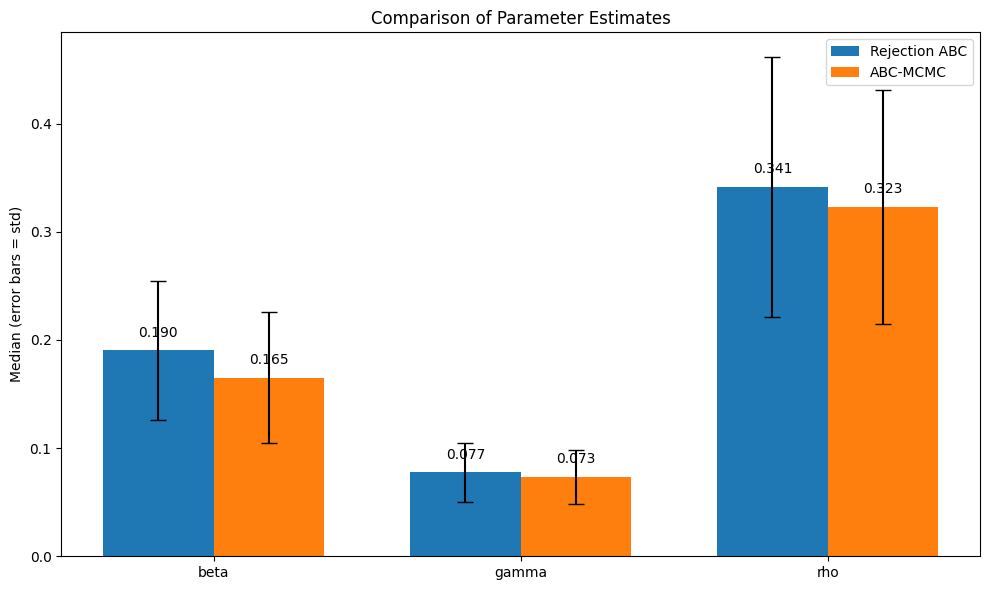

In [190]:
params = ["beta", "gamma", "rho"]

rej_samples = [beta_accepted_summary, gamma_accepted_summary, rho_accepted_summary]
mcmc_samples = [beta_mcmc, gamma_mcmc, rho_mcmc]

rej_medians = [np.median(x) for x in rej_samples]
rej_stds = [np.std(x) for x in rej_samples]

mcmc_medians = [np.median(x) for x in mcmc_samples]
mcmc_stds = [np.std(x) for x in mcmc_samples]

x = np.arange(len(params))
width = 0.36

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, rej_medians, width, yerr=rej_stds, capsize=6, label="Rejection ABC")
bars2 = plt.bar(x + width/2, mcmc_medians, width, yerr=mcmc_stds, capsize=6, label="ABC-MCMC")

plt.xticks(x, params)
plt.ylabel("Median (error bars = std)")
plt.title("Comparison of Parameter Estimates")
plt.legend()

for bars, vals in [(bars1, rej_medians), (bars2, mcmc_medians)]:
    for bar, val in zip(bars, vals):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

=== Rejection ABC ===
beta median = 0.1904, std = 0.0643
rho  median = 0.3412, std = 0.1202
corr(beta, rho) = 0.7694

=== ABC-MCMC ===
beta median = 0.1649, std = 0.0605
rho  median = 0.3227, std = 0.1084
corr(beta, rho) = 0.6632


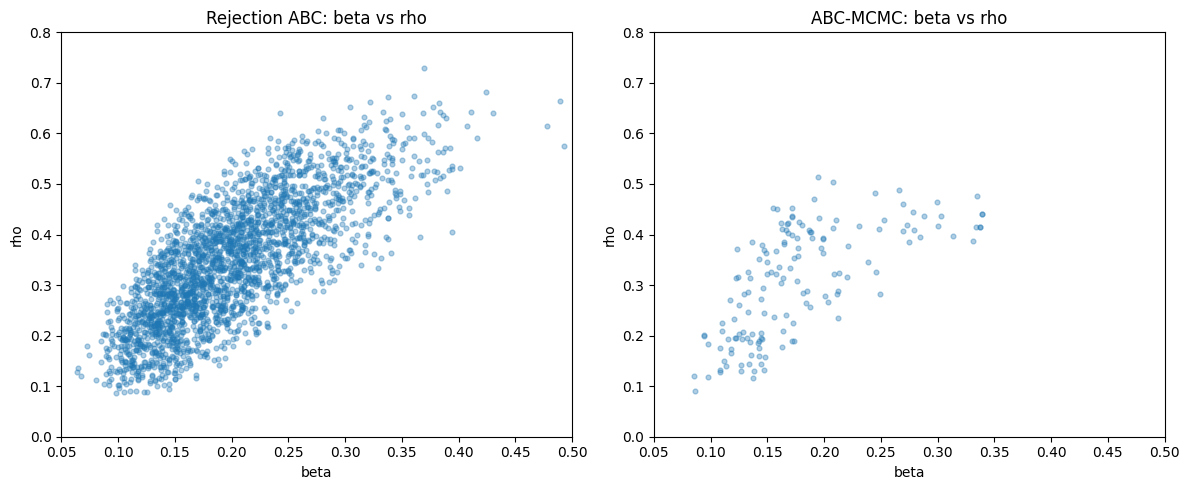

In [191]:
# AI is used to generate this part.
# -------------------------------
# Compare beta and rho
# -------------------------------

# Rejection ABC samples
beta_rej = beta_accepted_summary
rho_rej = rho_accepted_summary

# ABC-MCMC samples
beta_post = beta_mcmc
rho_post = rho_mcmc

# Summary numbers
print("=== Rejection ABC ===")
print(f"beta median = {np.median(beta_rej):.4f}, std = {np.std(beta_rej):.4f}")
print(f"rho  median = {np.median(rho_rej):.4f}, std = {np.std(rho_rej):.4f}")
print(f"corr(beta, rho) = {np.corrcoef(beta_rej, rho_rej)[0,1]:.4f}")

print("\n=== ABC-MCMC ===")
print(f"beta median = {np.median(beta_post):.4f}, std = {np.std(beta_post):.4f}")
print(f"rho  median = {np.median(rho_post):.4f}, std = {np.std(rho_post):.4f}")
print(f"corr(beta, rho) = {np.corrcoef(beta_post, rho_post)[0,1]:.4f}")

# -------------------------------
# Plot joint comparison
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Rejection ABC
axes[0].scatter(beta_rej, rho_rej, alpha=0.35, s=12)
axes[0].set_title("Rejection ABC: beta vs rho")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("rho")
axes[0].set_xlim(0.05, 0.5)
axes[0].set_ylim(0.0, 0.8)

# ABC-MCMC
axes[1].scatter(beta_post, rho_post, alpha=0.35, s=12)
axes[1].set_title("ABC-MCMC: beta vs rho")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("rho")
axes[1].set_xlim(0.05, 0.5)
axes[1].set_ylim(0.0, 0.8)

plt.tight_layout()
plt.show()

In [192]:
# AI is used to generate this part.
def ess(x):
    x = np.asarray(x)
    n = len(x)
    acf = np.correlate(x - x.mean(), x - x.mean(), mode='full')
    acf = acf[n-1:] / acf[n-1]

    positive_acf = acf[acf > 0]
    tau = 1 + 2 * np.sum(positive_acf[1:])

    return n / tau

post_chain_raw = chain[burn_in:]

print("ESS beta:", ess(post_chain_raw[:, 0]))
print("ESS gamma:", ess(post_chain_raw[:, 1]))
print("ESS rho:", ess(post_chain_raw[:, 2]))


ESS beta: 7.096506532547996
ESS gamma: 11.06748905393321
ESS rho: 4.55588014257248


# Advanced Method 3: SMC-ABC

Round 1: ε=2.0841  kept 200/500  (accept rate from prior=0.400)
  β: mean=0.2850  std=0.1074
  γ: mean=0.0808  std=0.0431
  ρ: mean=0.3721  std=0.1953
Round 2: ε=1.4720  accept=0.589  ESS=404/500
  β: mean=0.2682  std=0.1071
  γ: mean=0.0825  std=0.0418
  ρ: mean=0.3595  std=0.1866
Round 3: ε=1.1319  accept=0.249  ESS=451/500
  β: mean=0.2375  std=0.0974
  γ: mean=0.0758  std=0.0363
  ρ: mean=0.3843  std=0.1495
Round 4: ε=0.8732  accept=0.217  ESS=444/500
  β: mean=0.1943  std=0.0600
  γ: mean=0.0802  std=0.0274
  ρ: mean=0.3368  std=0.1171
Round 5: ε=0.6529  accept=0.200  ESS=399/500
  β: mean=0.1824  std=0.0453
  γ: mean=0.0811  std=0.0205
  ρ: mean=0.3310  std=0.0895
Round 6: ε=0.5000  accept=0.128  ESS=410/500
  β: mean=0.1724  std=0.0367
  γ: mean=0.0815  std=0.0162
  ρ: mean=0.3184  std=0.0694
Reached epsilon_min=0.5. Stopping.

=== Final SMC-ABC Posterior ===
  beta (β): mean=0.1724  std=0.0367  95% CI=[0.1197, 0.2361]
  gamma (γ): mean=0.0815  std=0.0162  95% CI=[0.0561, 0.1099

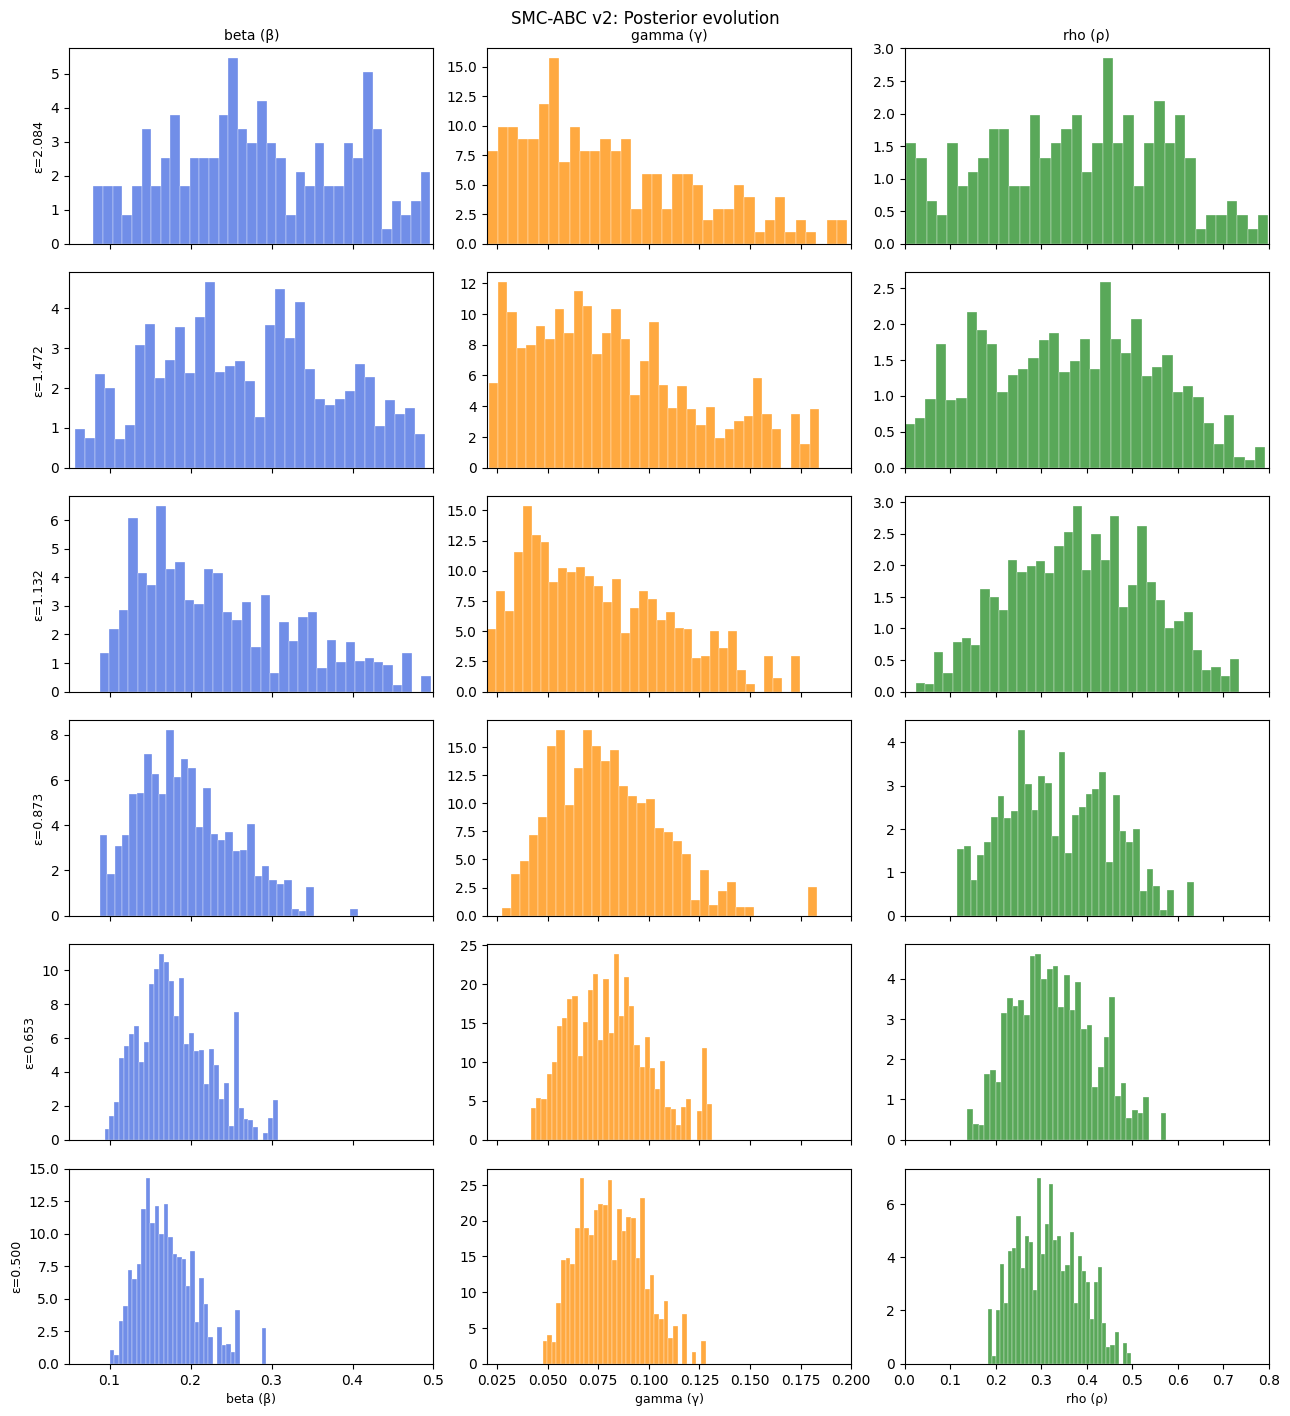

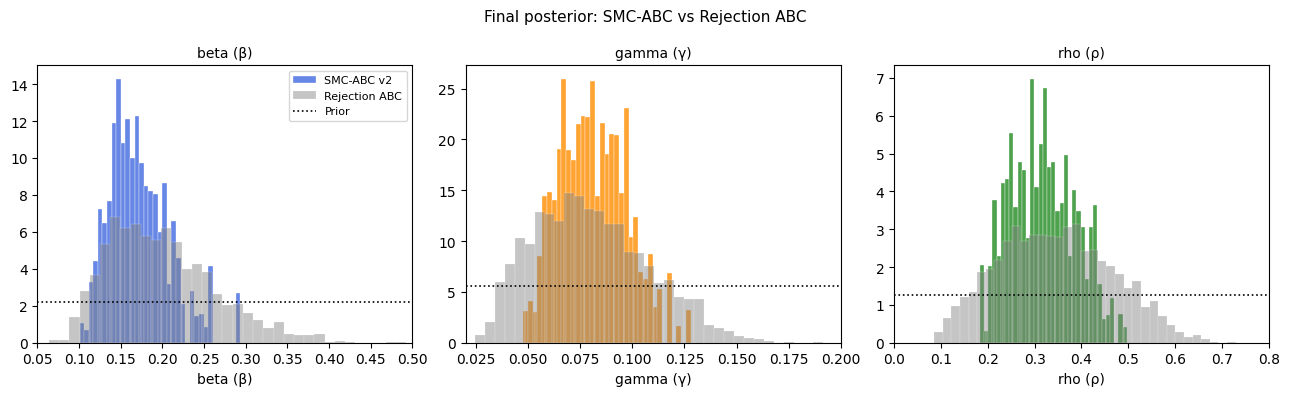

Done.


In [193]:
from numpy.linalg import slogdet

PRIOR_LO = np.array([0.05, 0.02, 0.00])
PRIOR_HI = np.array([0.50, 0.20, 0.80])

def sample_prior(rng):
    return rng.uniform(PRIOR_LO, PRIOR_HI)

def in_prior(theta):
    return np.all(theta >= PRIOR_LO) and np.all(theta <= PRIOR_HI)

def compute_distance(theta, obs_norm, sim_mean, sim_std, rng):
    beta, gamma, rho = theta
    inf, rew, deg = simulate(beta, gamma, rho, rng=rng)
    s = full_summary(inf, rew, deg)
    s_norm = (s - sim_mean) / sim_std
    return np.linalg.norm(s_norm - obs_norm)

# Gaussian kernel for perturbation and weight calculation

def perturb(theta, cov_diag, rng):
    return theta + rng.normal(0, np.sqrt(cov_diag))

def log_kernel(theta_new, theta_old, cov_diag):
    """Log of Gaussian kernel K(theta_new | theta_old)"""
    diff = theta_new - theta_old
    return -0.5 * np.sum(diff**2 / cov_diag)

# SMC-ABC with adaptive epsilon and Gaussian kernel proposal
# AI is used to generate this part of the code for adaptive epsilon and perturbation.

def run_smc_abc(
        obs_summary_mean,
        sim_mean,
        sim_std,
        N_particles     = 500,
        n_rounds        = 7,
        quantile_target = 0.3,    
        epsilon_min     = 0.5,    
        kernel_scale    = 0.5,    
        seed            = 0,
        verbose         = True,
):
    rng      = np.random.default_rng(seed)
    obs_norm = (obs_summary_mean - sim_mean) / sim_std

    particles_hist = []
    weights_hist   = []
    eps_hist       = []

    particles = None
    weights   = None

    for t in range(n_rounds):

        new_particles = []
        new_distances = []

        # Round 1: sample from prior
        if t == 0:
            n_attempts = 0
            while len(new_particles) < N_particles:
                theta = sample_prior(rng)
                d = compute_distance(theta, obs_norm, sim_mean, sim_std, rng)
                new_particles.append(theta)
                new_distances.append(d)
                n_attempts += 1

            new_particles = np.array(new_particles)
            new_distances = np.array(new_distances)

            # adaptive epsilon: quantile of distances
            epsilon = np.quantile(new_distances, quantile_target)
            mask    = new_distances <= epsilon
            new_particles = new_particles[mask]
            weights = np.ones(len(new_particles)) / len(new_particles)

            if verbose:
                print(f"Round 1: ε={epsilon:.4f}  "
                    f"kept {len(new_particles)}/{N_particles}  "
                    f"(accept rate from prior={len(new_particles)/n_attempts:.3f})")

        # AI-assisted: Rounds 2+: resample & perturb
        else:
            # proposal covariance: weighted variance of current particles
            wmean    = np.average(particles, weights=weights, axis=0)
            wvar     = np.average((particles - wmean)**2,
                                weights=weights, axis=0)
            cov_diag = (kernel_scale**2) * wvar + 1e-8

            accepted   = []
            acc_dist   = []
            n_proposed = 0
            max_prop   = N_particles * 500   # safety

            while len(accepted) < N_particles and n_proposed < max_prop:
                # resample
                idx       = rng.choice(len(particles), p=weights)
                theta_old = particles[idx]
                theta_new = perturb(theta_old, cov_diag, rng)
                n_proposed += 1

                if not in_prior(theta_new):
                    continue

                d = compute_distance(theta_new, obs_norm, sim_mean, sim_std, rng)

                if d <= epsilon:
                    accepted.append(theta_new)
                    acc_dist.append(d)

            if len(accepted) == 0:
                print(f"  Round {t+1}: no particles accepted at ε={epsilon:.4f}. Stopping.")
                break

            new_particles = np.array(accepted)
            new_distances = np.array(acc_dist)

            # update epsilon adaptively
            epsilon = max(np.quantile(new_distances, quantile_target),
                        epsilon_min)

            # log-space
            log_prior_val = 0.0 
            log_w = np.zeros(len(new_particles))
            for i, theta_new in enumerate(new_particles):
                log_kernels = np.array([
                    log_kernel(theta_new, particles[j], cov_diag)
                    for j in range(len(particles))
                ])
                # log-sum-exp
                log_denom = np.log(weights + 1e-300) + log_kernels
                lse       = np.max(log_denom) + np.log(
                    np.sum(np.exp(log_denom - np.max(log_denom))))
                log_w[i]  = log_prior_val - lse

            # normalise
            log_w -= np.max(log_w)
            w      = np.exp(log_w)
            weights = w / w.sum()

            accept_rate = len(accepted) / n_proposed
            ess = 1.0 / np.sum(weights**2)

            if verbose:
                print(f"Round {t+1}: ε={epsilon:.4f}  "
                    f"accept={accept_rate:.3f}  "
                    f"ESS={ess:.0f}/{len(new_particles)}")

        particles = new_particles

        particles_hist.append(particles.copy())
        weights_hist.append(weights.copy())
        eps_hist.append(epsilon)

        if verbose:
            for k, name in enumerate(['β','γ','ρ']):
                wm  = np.average(particles[:,k], weights=weights)
                wsd = np.sqrt(np.average(
                    (particles[:,k]-wm)**2, weights=weights))
                print(f"  {name}: mean={wm:.4f}  std={wsd:.4f}")

        if epsilon <= epsilon_min:
            print(f"Reached epsilon_min={epsilon_min}. Stopping.")
            break

    return particles_hist, weights_hist, eps_hist


# Run

sim_mean = sim_summaries.mean(axis=0)
sim_std  = sim_summaries.std(axis=0)
sim_std[sim_std == 0] = 1.0


particles_hist, weights_hist, eps_hist = run_smc_abc(
    obs_summary_mean = obs_summary_mean,
    sim_mean         = sim_mean,
    sim_std          = sim_std,
    N_particles      = 500,
    n_rounds         = 8,
    quantile_target  = 0.4,
    epsilon_min      = 0.5,
    kernel_scale     = 0.5,
    seed             = 0,
    verbose          = True,
)


final_particles = particles_hist[-1]
final_weights   = weights_hist[-1]

print("\n=== Final SMC-ABC Posterior ===")
for k, name in enumerate(['beta (β)', 'gamma (γ)', 'rho (ρ)']):
    vals = final_particles[:, k]
    wm   = np.average(vals, weights=final_weights)
    wsd  = np.sqrt(np.average((vals-wm)**2, weights=final_weights))
    p025 = np.percentile(vals, 2.5)
    p975 = np.percentile(vals, 97.5)
    print(f"  {name}: mean={wm:.4f}  std={wsd:.4f}  "
        f"95% CI=[{p025:.4f}, {p975:.4f}]")

# Plots are generated with the help of AI

import matplotlib.pyplot as plt

PARAM_NAMES = ['beta (β)', 'gamma (γ)', 'rho (ρ)']
COLORS      = ['royalblue', 'darkorange', 'forestgreen']
PRIORS      = [(0.05, 0.50), (0.02, 0.20), (0.00, 0.80)]

n_rounds = len(particles_hist)
fig, axes = plt.subplots(n_rounds, 3,
                        figsize=(13, 2.4*n_rounds), sharex='col')
fig.suptitle('SMC-ABC: Posterior evolution', fontsize=12)
for t, (parts, wts, eps) in enumerate(
        zip(particles_hist, weights_hist, eps_hist)):
    for col, (name, color, (lo, hi)) in enumerate(
            zip(PARAM_NAMES, COLORS, PRIORS)):
        ax = axes[t, col] if n_rounds > 1 else axes[col]
        ax.hist(parts[:, col], bins=35,
                weights=wts * len(wts),
                density=True, color=color,
                alpha=0.75, edgecolor='white', lw=0.3)
        ax.set_xlim(lo, hi)
        if col == 0: ax.set_ylabel(f'ε={eps:.3f}', fontsize=9)
        if t == 0:   ax.set_title(name, fontsize=10)
        if t == n_rounds-1: ax.set_xlabel(name, fontsize=9)
plt.tight_layout()
plt.savefig('smc_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

# Final vs Rejection ABC
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4))
fig2.suptitle('Final posterior: SMC-ABC vs Rejection ABC', fontsize=11)
for col, (name, color, (lo, hi)) in enumerate(
        zip(PARAM_NAMES, COLORS, PRIORS)):
    ax = axes2[col]
    ax.hist(final_particles[:, col],
            bins=35, weights=final_weights*len(final_weights),
            density=True, color=color, alpha=0.8,
            edgecolor='white', lw=0.3, label='SMC-ABC')
    rej = [beta_accepted_summary,
        gamma_accepted_summary,
        rho_accepted_summary][col]
    ax.hist(rej, bins=35, density=True,
            color='grey', alpha=0.45,
            edgecolor='white', lw=0.3, label='Rejection ABC')
    ax.axhline(1/(hi-lo), color='black', lw=1.2,
            linestyle=':', label='Prior')
    ax.set_xlim(lo, hi)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(name)
    if col == 0: ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('smc_vs_rejection.png', dpi=120, bbox_inches='tight')
plt.show()
print("Done.")

=== ADDITION 1: Synthetic Truth Recovery ===
True parameters: β=0.18, γ=0.07, ρ=0.35
Synthetic S_obs: [0.7155 8.2    0.0145 0.5648 0.2322 0.1089]

Running SMC-ABC on synthetic data...
Reached epsilon_min=0.5. Stopping.

=== Synthetic Truth Recovery Results ===
Param        True     Mean      Std               90% CI   Covered?
-----------------------------------------------------------------
β          0.1800   0.1954   0.0427 [0.1379, 0.2549]  ✓
γ          0.0700   0.0721   0.0156 [0.0499, 0.0932]  ✓
ρ          0.3500   0.3650   0.0774 [0.2557, 0.4741]  ✓

90% CI coverage: 3/3 parameters


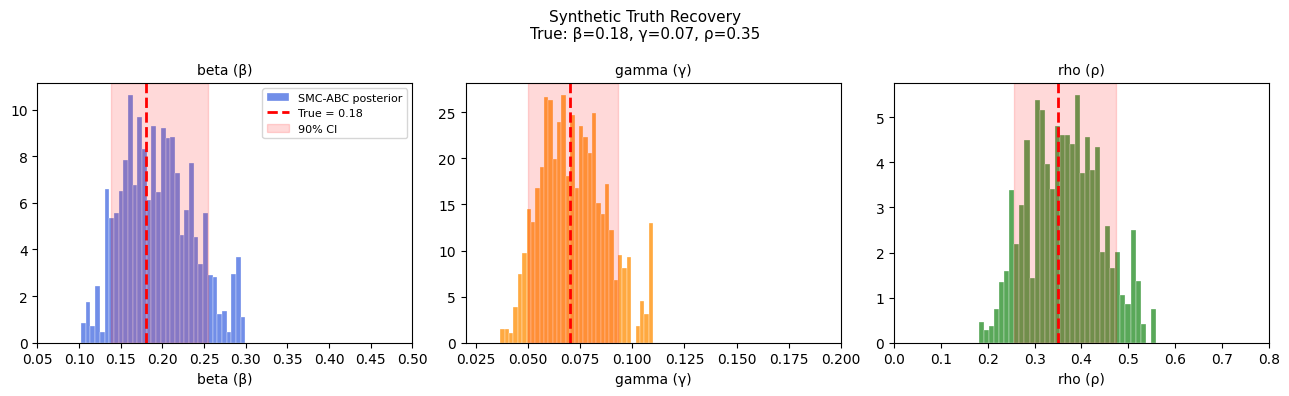

Saved: synthetic_truth_recovery.png


In [29]:
#Synthetic Truth Recovery with SMC-ABC
THETA_TRUE = np.array([0.18, 0.07, 0.35]) 
N_SYNTHETIC = 20 

print("=== ADDITION 1: Synthetic Truth Recovery ===")
print(f"True parameters: β={THETA_TRUE[0]}, γ={THETA_TRUE[1]}, ρ={THETA_TRUE[2]}")

# Generate synthetic datasets using the true parameters
rng_synth = np.random.default_rng(999)
synth_infected = []
synth_rewire   = []
synth_degree   = []

for _ in range(N_SYNTHETIC):
    inf, rew, deg = simulate(*THETA_TRUE, rng=rng_synth)
    synth_infected.append(inf)
    synth_rewire.append(rew)
    synth_degree.append(deg)

synth_summaries = np.array([
    full_summary(synth_infected[i], synth_rewire[i], synth_degree[i])
    for i in range(N_SYNTHETIC)
])
synth_obs_mean = synth_summaries.mean(axis=0)

print(f"Synthetic S_obs: {synth_obs_mean.round(4)}")
print("\nRunning SMC-ABC on synthetic data...")
synth_particles_hist, synth_weights_hist, synth_eps_hist = run_smc_abc(
    obs_summary_mean = synth_obs_mean,
    sim_mean         = sim_mean,
    sim_std          = sim_std,
    N_particles      = 500,
    n_rounds         = 8,
    quantile_target  = 0.4,
    epsilon_min      = 0.5,
    kernel_scale     = 0.5,
    seed             = 1,
    verbose          = False,
)

synth_final   = synth_particles_hist[-1]
synth_weights = synth_weights_hist[-1]

# AI-assisted for the results and plots for synthetic truth recovery for better formatting and clarity.
print("\n=== Synthetic Truth Recovery Results ===")
print(f"{'Param':<8} {'True':>8} {'Mean':>8} {'Std':>8} {'90% CI':>20} {'Covered?':>10}")
print("-" * 65)
covered = []
for k, (name, true_val) in enumerate(
        zip(['β','γ','ρ'], THETA_TRUE)):
    vals = synth_final[:, k]
    wm   = np.average(vals, weights=synth_weights)
    wsd  = np.sqrt(np.average((vals-wm)**2, weights=synth_weights))
    lo5  = np.percentile(vals, 5)
    hi95 = np.percentile(vals, 95)
    cov  = lo5 <= true_val <= hi95
    covered.append(cov)
    print(f"{name:<8} {true_val:>8.4f} {wm:>8.4f} {wsd:>8.4f} "
        f"[{lo5:.4f}, {hi95:.4f}]  {'✓' if cov else '✗'}")

print(f"\n90% CI coverage: {sum(covered)}/3 parameters")


fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Synthetic Truth Recovery\n'
            f'True: β={THETA_TRUE[0]}, γ={THETA_TRUE[1]}, ρ={THETA_TRUE[2]}',
            fontsize=11)
PARAM_NAMES = ['beta (β)', 'gamma (γ)', 'rho (ρ)']
COLORS = ['royalblue', 'darkorange', 'forestgreen']
PRIORS = [(0.05,0.50),(0.02,0.20),(0.00,0.80)]

for col, (name, color, (lo,hi), true_val) in enumerate(
        zip(PARAM_NAMES, COLORS, PRIORS, THETA_TRUE)):
    ax = axes[col]
    vals = synth_final[:, col]
    ax.hist(vals, bins=35, weights=synth_weights*len(synth_weights),
            density=True, color=color, alpha=0.75,
            edgecolor='white', lw=0.3, label='SMC-ABC posterior')
    ax.axvline(true_val, color='red', lw=2, linestyle='--', label=f'True = {true_val}')
    p5  = np.percentile(vals, 5)
    p95 = np.percentile(vals, 95)
    ax.axvspan(p5, p95, alpha=0.15, color='red', label='90% CI')
    ax.set_xlim(lo, hi)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(name)
    if col == 0: ax.legend(fontsize=8)                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

plt.tight_layout()
plt.savefig('synthetic_truth_recovery.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: synthetic_truth_recovery.png")


=== ADDITION 2: Posterior Predictive Check ===
Running 50 posterior predictive simulations...


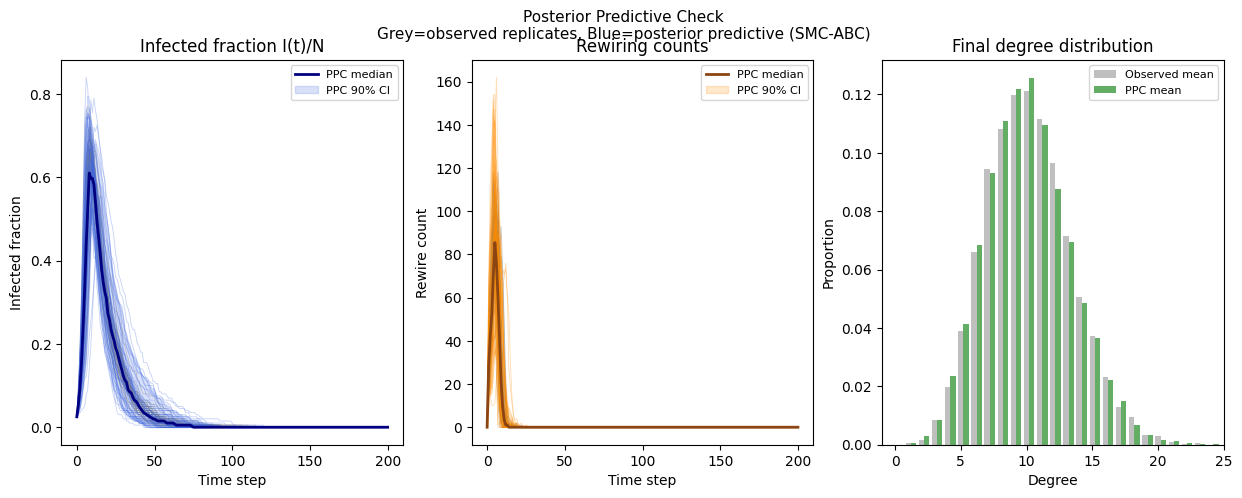

In [54]:
# Posterior Predictive Check

print("\n=== ADDITION 2: Posterior Predictive Check ===")

rng_ppc = np.random.default_rng(42)
N_PPC   = 50
ppc_idx = rng_ppc.choice(len(final_particles), size=N_PPC,
                        p=final_weights, replace=True)
ppc_params = final_particles[ppc_idx]

ppc_infected = []
ppc_rewire   = []
ppc_degree   = []

print(f"Running {N_PPC} posterior predictive simulations...")
for theta in ppc_params:
        inf, rew, deg = simulate(*theta, rng=rng_ppc)
        ppc_infected.append(inf)
        ppc_rewire.append(rew)
        ppc_degree.append(deg)

ppc_infected = np.array(ppc_infected)  # (N_PPC, 201)
ppc_rewire   = np.array(ppc_rewire)    # (N_PPC, 201)
ppc_degree   = np.array(ppc_degree)    # (N_PPC, 31)

T = np.arange(201)
degrees = np.arange(31)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Posterior Predictive Check\n'
        'Grey=observed replicates, Blue=posterior predictive (SMC-ABC)',
        fontsize=11)

# AI-assisted: fill-between plot for infected fraction time series
ax = axes[0]
for i in range(real_infected_matrix.shape[0]):
        ax.plot(T, real_infected_matrix[i], color='grey',
        lw=0.6, alpha=0.4)
for i in range(N_PPC):
        ax.plot(T, ppc_infected[i], color='royalblue',
        lw=0.6, alpha=0.3)

ppc_med = np.median(ppc_infected, axis=0)
ppc_lo  = np.percentile(ppc_infected, 5,  axis=0)
ppc_hi  = np.percentile(ppc_infected, 95, axis=0)
ax.plot(T, ppc_med, color='navy', lw=2, label='PPC median')
ax.fill_between(T, ppc_lo, ppc_hi, color='royalblue', alpha=0.2, label='PPC 90% CI')
ax.set_xlabel('Time step')
ax.set_ylabel('Infected fraction')
ax.set_title('Infected fraction I(t)/N')
ax.legend(fontsize=8)

# AI-assisted with the plots of rewire counts
ax = axes[1]
for i in range(real_rewire_matrix.shape[0]):
        ax.plot(T, real_rewire_matrix[i], color='grey',
        lw=0.6, alpha=0.4)
for i in range(N_PPC):
        ax.plot(T, ppc_rewire[i], color='darkorange',
        lw=0.6, alpha=0.3)
rew_med = np.median(ppc_rewire, axis=0)
rew_lo  = np.percentile(ppc_rewire, 5,  axis=0)
rew_hi  = np.percentile(ppc_rewire, 95, axis=0)
ax.plot(T, rew_med, color='saddlebrown', lw=2, label='PPC median')
ax.fill_between(T, rew_lo, rew_hi, color='darkorange', alpha=0.2, label='PPC 90% CI')
ax.set_xlabel('Time step')
ax.set_ylabel('Rewire count')
ax.set_title('Rewiring counts')
ax.legend(fontsize=8)

# AI-assisted: degree histogram side-by-side bar chart
ax = axes[2]
obs_deg_mean = real_degree_matrix.mean(axis=0)
ax.bar(degrees, obs_deg_mean / obs_deg_mean.sum(),
        color='grey', alpha=0.5, label='Observed mean', width=0.4)
ppc_deg_mean = ppc_degree.mean(axis=0)
ax.bar(degrees + 0.4, ppc_deg_mean / ppc_deg_mean.sum(),
        color='forestgreen', alpha=0.7, label='PPC mean', width=0.4)
ax.set_xlabel('Degree')
ax.set_ylabel('Proportion')
ax.set_title('Final degree distribution')
ax.set_xlim(-1, 25)
ax.legend(fontsize=8)
